<a href="https://colab.research.google.com/github/123fakhar/spam-detection-ml/blob/main/SMS_Spam_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas scikit-learn matplotlib

In [2]:
import pandas as pd
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    names=["label", "text"]
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df["text"] = df["text"].apply(preprocess)
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,text
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier', MultinomialNB())])

In [7]:
y_pred = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9632

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



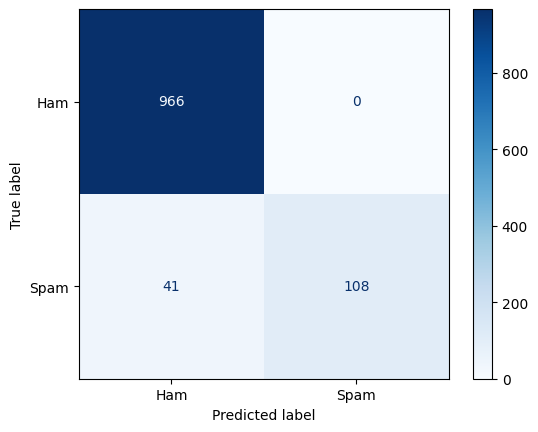

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")
plt.show()

In [10]:
while True:
    msg = input("Enter an SMS message (or type 'exit' to quit): ")

    if msg.lower() == "exit":
        break

    prediction = model.predict([msg])[0]

    if prediction == 1:
        print("🚨 Prediction: Spam\n")
    else:
        print("✅ Prediction: Ham\n")

Enter an SMS message (or type 'exit' to quit): How about nice big cup of tea without sugar
✅ Prediction: Ham

Enter an SMS message (or type 'exit' to quit): 100% free
🚨 Prediction: Spam

Enter an SMS message (or type 'exit' to quit): exit
